# Projet HISTA

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import urllib.request

import GEOparse
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, LogisticRegression, LogisticRegressionCV, lasso_path
from sklearn.datasets import load_diabetes, load_breast_cancer, load_wine
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_selection import SelectKBest, f_classif


SEED = 42

np.random.seed(SEED)  # Pour avoir toujours les mêmes résultats



## Question 2.1 — Génération des données

On génère $n = 20$ paires $(X_i, Y_i)$ avec :
- $X_i \sim N(0, I_8)$ dans $\mathbb{R}^8$
- $Y_i = X_i^T \beta^* + \varepsilon_i$, avec $\varepsilon_i \sim N(0, 1)$
- $\beta^* = (5, 3, 0, 0, 1.5, 0, 0, 0)^T$

Dans ce notebook, nous travaillons **sans standardisation** de $X$, conformément à l'esprit de l'exercice qui génère les données depuis $N(0, I_8)$ (déjà approximativement standardisé). Cela évite la confusion entre les coefficients dans l'espace original et l'espace standardisé.

**Limite :** Pour $n = 20$ observations en dimension $d = 8$, les propriétés empiriques de $X$ peuvent s'écarter sensiblement de la théorie. Les résultats sont donc sensible à l'aléatoire (c'est pour ça qu'on impose la seed). (j'ai mis mon chiffre fétiche)

In [13]:
# On recopie les paramètres de l'énoncé et on génère les différents paramètres
n = 20
p = 8
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])

X = np.random.multivariate_normal(np.zeros(p), np.eye(p), size=n)
epsilon = np.random.normal(0, 1, size=n)
y = X @ beta_star + epsilon

# Nous devons bien standardiser les données comme le dit Tibishirani
# #afin que la pénialité L1 soit équitable entre les coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Affichage pour vérification
print("Dimensions de X_scaled :", X_scaled.shape)
print("Vecteur beta* :", beta_star)

Dimensions de X_scaled : (20, 8)
Vecteur beta* : [5.  3.  0.  0.  1.5 0.  0.  0. ]


## Question 2.2 — Erreur de prédiction in-sample en fonction de $\lambda$

On trace la fonction :
$$\lambda \mapsto \|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$$


Comme demandé, on évalue la fonction pour $\lambda \in \{0.01, 0.02, \ldots, 2.00\}$.

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78867/195698142.py:33: SyntaxWarning: invalid escape sequence '\l'
  label=f'$\lambda$ optimal $\\approx$ {lambda_opt:.2f}')


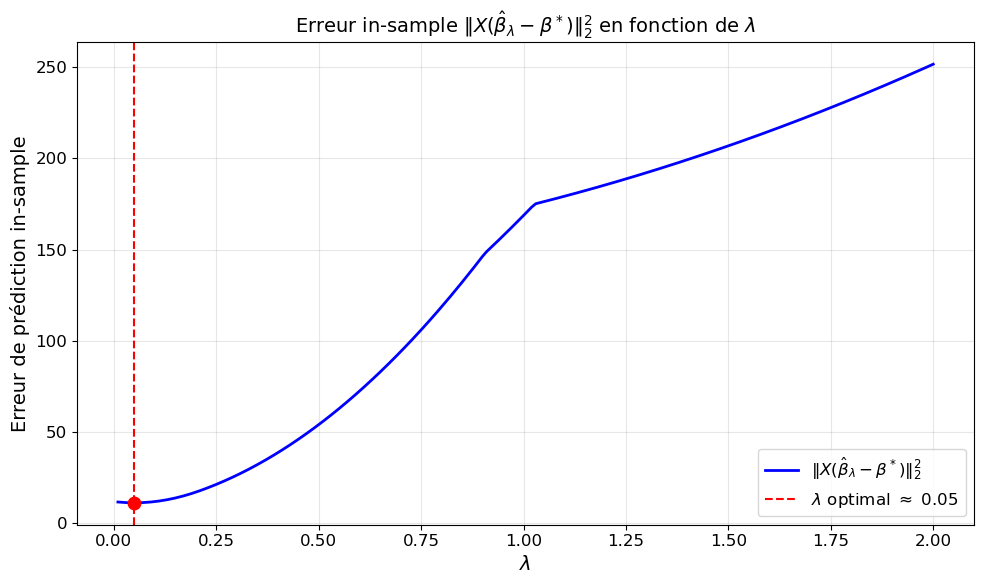

Lambda optimal (in-sample) : 0.05
Erreur minimale : 11.21

Coefficients β̂ au lambda optimal :
  [ 4.3786  2.7733  0.0617 -0.1655  1.7835 -0.     -0.2726  0.0668]
  (rappel : β* = [5.  3.  0.  0.  1.5 0.  0.  0. ])


In [14]:
# Grille de lambda comme demandé dans l'énoncé
lambdas = np.arange(0.01, 2.01, 0.01)

# Calcul des estimateurs LASSO et des erreurs pour chaque lambda
errors_in_sample = []
coefficients = []

for lam in lambdas:
    model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    model.fit(X, y)

    beta_hat = model.coef_
    coefficients.append(beta_hat.copy())

    # Erreur de prédiction in-sample : ||X(β̂_λ - β*)||₂²
    diff = beta_hat - beta_star
    error = np.sum((X @ diff) ** 2)
    errors_in_sample.append(error)

errors_in_sample = np.array(errors_in_sample)
coefficients = np.array(coefficients)

# Lambda optimal (minimisant l'erreur in-sample)
idx_opt = np.argmin(errors_in_sample)
lambda_opt = lambdas[idx_opt]
error_opt = errors_in_sample[idx_opt]

# Tracé
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambdas, errors_in_sample, 'b-', linewidth=2,
        label=r'$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$')
ax.axvline(x=lambda_opt, color='red', linestyle='--', linewidth=1.5,
           label=f'$\lambda$ optimal $\\approx$ {lambda_opt:.2f}')
ax.scatter([lambda_opt], [error_opt], color='red', s=80, zorder=5)

ax.set_xlabel(r'$\lambda$', fontsize=14)
ax.set_ylabel('Erreur de prédiction in-sample', fontsize=14)
ax.set_title(r"Erreur in-sample $\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$ en fonction de $\lambda$", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Lambda optimal (in-sample) : {lambda_opt:.2f}")
print(f"Erreur minimale : {error_opt:.2f}")
print(f"\nCoefficients β̂ au lambda optimal :")
print(f"  {coefficients[idx_opt].round(4)}")
print(f"  (rappel : β* = {beta_star})")

### Discussion sur le $\lambda$ optimal in-sample

On a trouvé un $\lambda$ proche de $0$, ce qui est expliqué dans le rapport, il et tout de fois important de signaler qu'avec une autre side les résutats varient beaucoup. D'autres figures sertont présentées en annexe du rapport.

## Question 2.3 — Sélection de $\lambda$ par validation croisée

### Principe de la validation croisée

En pratique, $\beta^*$ est inconnu, ici on utilise la croo-validation pour le selectionner.

Tibshirani utilise la **5-fold cross-validation** pour estimer l'erreur de prédiction. Nous suivons cette convention.



<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78867/2844783796.py:32: SyntaxWarning: invalid escape sequence '\l'
  label=f'$\lambda_{{CV}}$ = {lambda_cv:.2f}')
/tmp/ipykernel_78867/2844783796.py:34: SyntaxWarning: invalid escape sequence '\l'
  label=f'$\lambda_{{optimal}}$ = {lambda_opt:.2f}')


Lambda sélectionné par 5-fold CV : 0.03
Lambda optimal (Q2.2) :     0.05


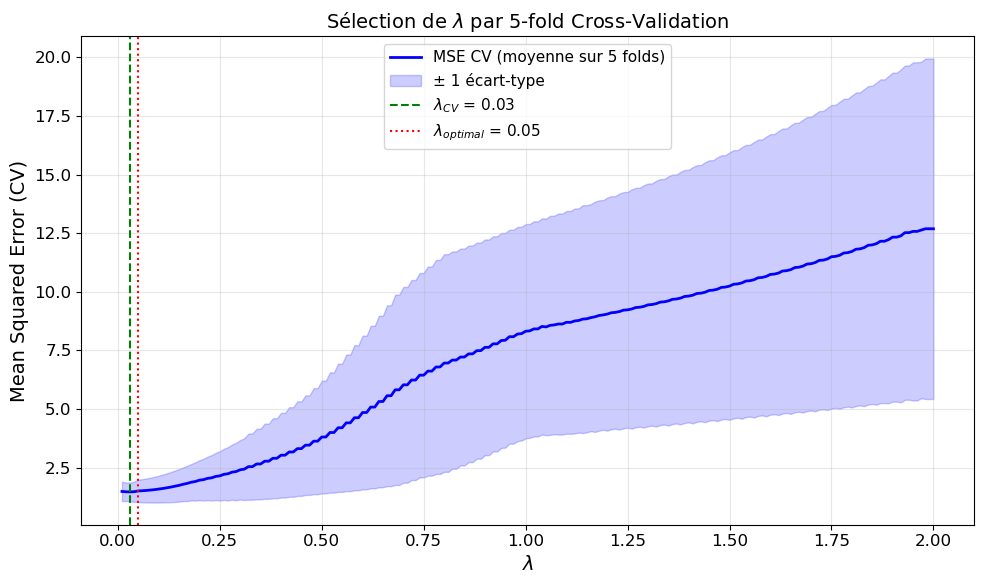


Coefficients β̂ au λ_CV :
  [ 4.4866  2.8153  0.0788 -0.1831  1.8167 -0.     -0.3089  0.0767]
  (rappel : β* = [5.  3.  0.  0.  1.5 0.  0.  0. ])

Erreur in-sample au λ_CV :     11.31
Erreur in-sample au λ_optimal_precedant : 11.21


In [15]:
# 5-fold Cross-Validation pour sélection de lambda
# On utilise LassoCV de sklearn avec la même grille de lambdas

model_cv = LassoCV(
    alphas=lambdas,  # alpha sklearn = lambda de l'énoncé
    cv=5,            # 5-fold CV comme Tibshirani
    fit_intercept=False,
    max_iter=10000
)
model_cv.fit(X, y)

# Lambda sélectionné par CV
lambda_cv = model_cv.alpha_
print(f"Lambda sélectionné par 5-fold CV : {lambda_cv:.2f}")
print(f"Lambda optimal (Q2.2) :     {lambda_opt:.2f}")

# Erreur CV moyenne pour chaque lambda
mse_mean = model_cv.mse_path_.mean(axis=1)
mse_std = model_cv.mse_path_.std(axis=1)

# Attention : les alphas dans LassoCV sont triés par ordre décroissant
# Il faut les retourner pour correspondre à notre grille croissante
alphas_cv = model_cv.alphas_

# Tracé de l'erreur CV
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(alphas_cv, mse_mean, 'b-', linewidth=2, label='MSE CV (moyenne sur 5 folds)')
ax.fill_between(alphas_cv, mse_mean - mse_std, mse_mean + mse_std,
                alpha=0.2, color='blue', label='± 1 écart-type')
ax.axvline(x=lambda_cv, color='green', linestyle='--', linewidth=1.5,
           label=f'$\lambda_{{CV}}$ = {lambda_cv:.2f}')
ax.axvline(x=lambda_opt, color='red', linestyle=':', linewidth=1.5,
           label=f'$\lambda_{{optimal}}$ = {lambda_opt:.2f}')

ax.set_xlabel(r'$\lambda$', fontsize=14)
ax.set_ylabel('Mean Squared Error (CV)', fontsize=14)
ax.set_title(r'Sélection de $\lambda$ par 5-fold Cross-Validation', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Coefficients au lambda CV
beta_cv = model_cv.coef_
print(f"\nCoefficients β̂ au λ_CV :")
print(f"  {beta_cv.round(4)}")
print(f"  (rappel : β* = {beta_star})")

# Erreur in-sample au lambda CV
idx_cv = np.argmin(np.abs(lambdas - lambda_cv))
error_cv = errors_in_sample[idx_cv]
print(f"\nErreur in-sample au λ_CV :     {error_cv:.2f}")
print(f"Erreur in-sample au λ_optimal_precedant : {error_opt:.2f}")

## Question 2.4 — Norme $L_0$ (parcimonie) en fonction de $\lambda$

On trace la fonction :
$$\lambda \mapsto \|\hat{\beta}_\lambda\|_0$$

où $\|\beta\|_0$ compte le nombre de composantes non nulles de $\beta$



Puisque $\beta^* = (5, 3, 0, 0, 1.5, 0, 0, 0)^T$ a $\|\beta^*\|_0 = 3$, on espère trouver un $\lambda$ pour lequel $\|\hat{\beta}_\lambda\|_0 = 3$ et les bonnes variables sont sélectionnées (indices 0, 1, 4).

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78867/379970935.py:14: SyntaxWarning: invalid escape sequence '\l'
  label=f'$\lambda_{{optimal}}$ = {lambda_opt:.2f}')
/tmp/ipykernel_78867/379970935.py:16: SyntaxWarning: invalid escape sequence '\l'
  label=f'$\lambda_{{CV}}$ = {lambda_cv:.2f}')


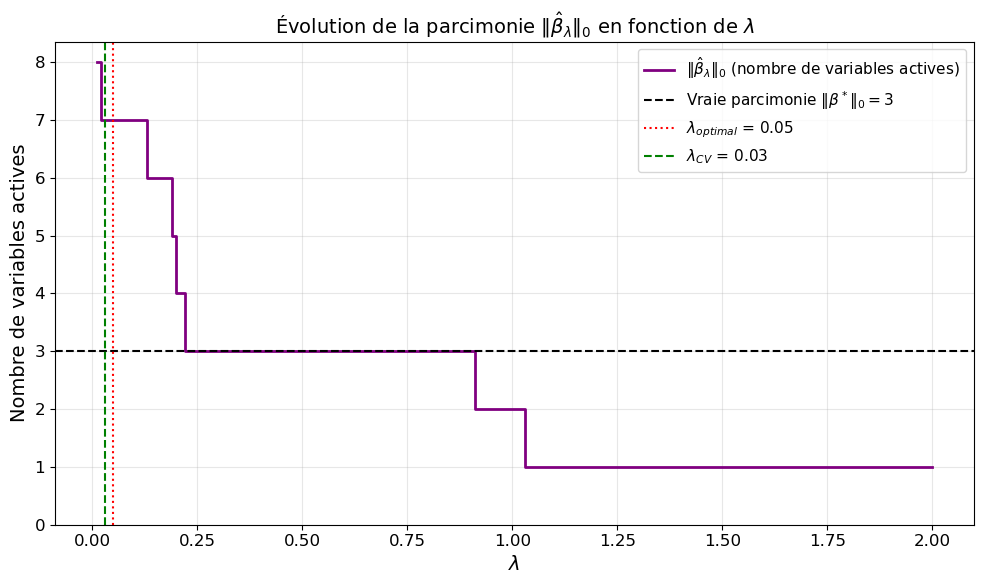

Au λ_optimal = 0.05 :
  ||β̂||₀ = 7
  Variables actives (indices) : [0 1 2 3 4 6 7]
  Coefficients : [ 4.3786  2.7733  0.0617 -0.1655  1.7835 -0.     -0.2726  0.0668]

Au λ_CV = 0.03 :
  ||β̂||₀ = 7
  Variables actives (indices) : [0 1 2 3 4 6 7]
  Coefficients : [ 4.4866  2.8153  0.0788 -0.1831  1.8167 -0.     -0.3089  0.0767]

Rappel : β* = [5.  3.  0.  0.  1.5 0.  0.  0. ]
Variables véritablement actives : [0 1 4]


In [16]:
# Calcul de la norme L0 pour chaque lambda
# Un coefficient est considéré "non nul" si |β_j| > 1e-5 (seuil numérique)
threshold = 1e-5
l0_norms = np.array([np.sum(np.abs(c) > threshold) for c in coefficients])

# Tracé
fig, ax = plt.subplots(figsize=(10, 6))

ax.step(lambdas, l0_norms, where='post', color='purple', linewidth=2,
        label=r'$\|\hat{\beta}_\lambda\|_0$ (nombre de variables actives)')
ax.axhline(y=3, color='black', linestyle='--', linewidth=1.5,
           label=r'Vraie parcimonie $\|\beta^*\|_0 = 3$')
ax.axvline(x=lambda_opt, color='red', linestyle=':', linewidth=1.5,
           label=f'$\lambda_{{optimal}}$ = {lambda_opt:.2f}')
ax.axvline(x=lambda_cv, color='green', linestyle='--', linewidth=1.5,
           label=f'$\lambda_{{CV}}$ = {lambda_cv:.2f}')

ax.set_xlabel(r'$\lambda$', fontsize=14)
ax.set_ylabel('Nombre de variables actives', fontsize=14)
ax.set_title(r"Évolution de la parcimonie $\|\hat{\beta}_\lambda\|_0$ en fonction de $\lambda$", fontsize=14)
ax.set_yticks(range(0, p + 1))
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Détails au lambda optimal et lambda CV
print(f"Au λ_optimal = {lambda_opt:.2f} :")
idx_o = np.argmin(np.abs(lambdas - lambda_opt))
print(f"  ||β̂||₀ = {l0_norms[idx_o]}")
print(f"  Variables actives (indices) : {np.where(np.abs(coefficients[idx_o]) > threshold)[0]}")
print(f"  Coefficients : {coefficients[idx_o].round(4)}")

print(f"\nAu λ_CV = {lambda_cv:.2f} :")
idx_c = np.argmin(np.abs(lambdas - lambda_cv))
print(f"  ||β̂||₀ = {l0_norms[idx_c]}")
print(f"  Variables actives (indices) : {np.where(np.abs(coefficients[idx_c]) > threshold)[0]}")
print(f"  Coefficients : {coefficients[idx_c].round(4)}")

print(f"\nRappel : β* = {beta_star}")
print(f"Variables véritablement actives : {np.where(beta_star != 0)[0]}")

## Question 3

On travaille ici sur des données réelles de classification (cancer du sein). La cible est binaire, ce qui justifie l'utilisation d'une régression logistique avec pénalité Lasso.

In [17]:
# Chargement des données depuis le dépôt UCI
# Documentation : https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis']

features = X.columns

print(breast_cancer_wisconsin_diagnostic.metadata)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [18]:
# Aperçu des données
print(X.head(5))
print(y.head(5))


   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

La cible est binaire (M = malin, B = bénin), ce qui justifie l'utilisation d'une régression logistique. Cela correspond exactement à la section 8.1 de l'article, qui étend le Lasso au cadre de la vraisemblance maximale pénalisée.

In [19]:
# Prétraitement des données
y_encoded = np.where(y == 'M', 1, 0)  # Encodage binaire de la cible (M=1, B=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:

# sklearn utilise C = 1/lambda, contrairement à la convention de l'exercice 1
Cs = 1 / lambdas

coefs = []
for c in Cs:
    # Le solver liblinear est requis pour la pénalité L1
    clf = LogisticRegression(l1_ratio=1, C=c, solver='liblinear', random_state=SEED)
    clf.fit(X_scaled, y_encoded)
    coefs.append(clf.coef_[0])

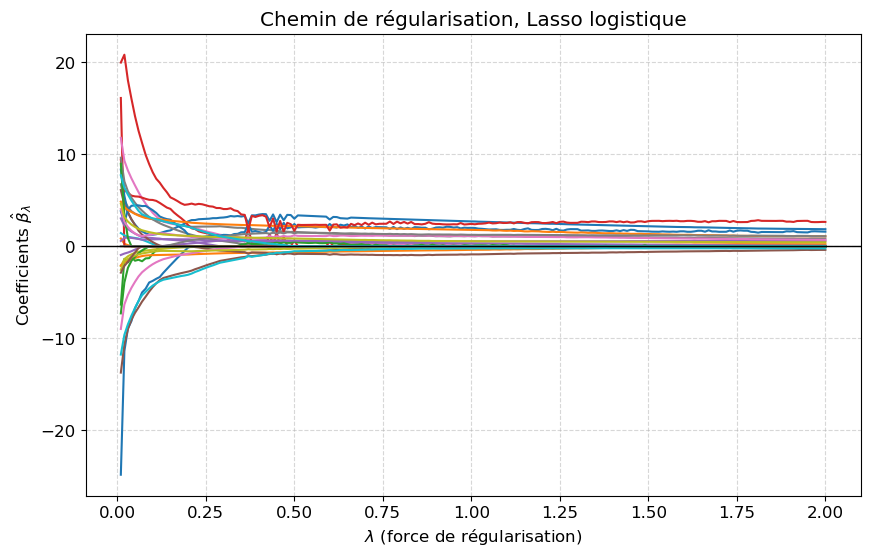

In [21]:
coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(lambdas, coefs[:, i])

plt.xlabel(r'$\lambda$ (force de régularisation)')
plt.ylabel(r'Coefficients $\hat{\beta}_\lambda$')
plt.title('Chemin de régularisation, Lasso logistique')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.show()


In [22]:
clf_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    l1_ratios=(1,),
    solver='liblinear',
    max_iter=5000,
    tol=1e-3,
    random_state=SEED,
    use_legacy_attributes=True
)

clf_cv.fit(X_scaled, y_encoded)

best_C = clf_cv.C_[0]
best_lambda = 1 / best_C

print(f'Valeur optimale de C : {best_C:.4f}')
print(f'Lambda optimal : {best_lambda:.4f}\n')

# Coefficients au lambda optimal
optimal_coefs = clf_cv.coef_[0]


threshold = 1e-6
active_mask = np.abs(optimal_coefs) > threshold

active_vars = np.array(features)[active_mask]
active_weights = optimal_coefs[active_mask]

print(f'Variables actives ({len(active_vars)} sur {len(features)}) :')

# Tri par valeur absolue décroissante
sorted_indices = np.argsort(np.abs(active_weights))[::-1]

for idx in sorted_indices:
    print(f'{active_vars[idx]:<25}: {active_weights[idx]:.4f}')

Valeur optimale de C : 1.2048
Lambda optimal : 0.8300

Variables actives (21 sur 30) :
radius3                  : 1.8236
radius2                  : 1.7479
area2                    : 1.6845
texture3                 : 1.4939
area3                    : 1.3268
concave_points3          : 1.2607
concavity3               : 1.0371
perimeter3               : 1.0211
concave_points1          : 0.9649
compactness2             : -0.9486
symmetry3                : 0.6693
smoothness3              : 0.6669
concavity1               : 0.3848
smoothness2              : 0.2561
texture2                 : -0.2490
fractal_dimension2       : -0.2447
texture1                 : 0.2270
fractal_dimension1       : -0.1725
symmetry2                : -0.1028
compactness1             : -0.0791
concave_points2          : 0.0270


## Bonus : Lasso sur autres jeux de données

Un **chemin de régularisation** trace l'évolution des coefficients $\hat\beta_j(\lambda)$ lorsque $\lambda$ varie de petit (peu de régularisation) à grand (modèle nul). On illustre ici le chemin Lasso sur les trois jeux de données réels. Les coefficients dont la trajectoire est **non-monotone** (leur valeur absolue remonte à un moment donné lorsque $\lambda$ croît) sont tracés en rouge.

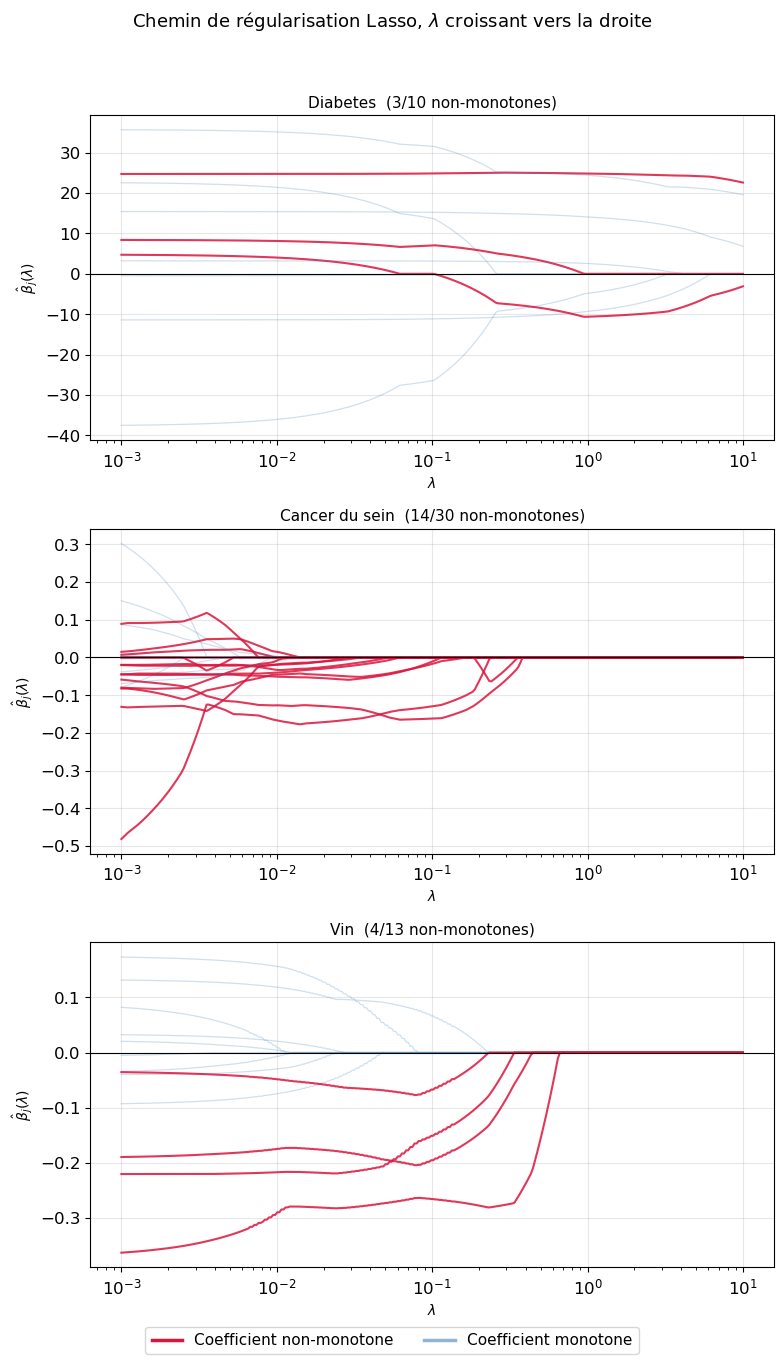

In [23]:
alphas_path = np.logspace(1, -3, 300)

DATASETS_BONUS = [
    ('Diabetes', load_diabetes()),
    ('Cancer du sein', load_breast_cancer()),
    ('Vin', load_wine()),
]

def detect_non_monotone(coefs_desc, tol=1e-6):
    return np.any(np.diff(np.abs(coefs_desc), axis=1) < -tol, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(8, 13))
fig.suptitle(
    r'Chemin de régularisation Lasso, $\lambda$ croissant vers la droite',
    fontsize=13, y=1.02
)

for row, (ds_name, data) in enumerate(DATASETS_BONUS):
    X_d = StandardScaler().fit_transform(data.data)
    y_d = data.target.astype(float)
    y_d -= y_d.mean()
    p_d = X_d.shape[1]

    alphas_lasso, coefs_lasso, _ = lasso_path(X_d, y_d, alphas=alphas_path)
    mask_lasso = detect_non_monotone(coefs_lasso)
    lam_plot = alphas_lasso[::-1]
    coefs_plot = coefs_lasso[:, ::-1]
    n_nm = int(mask_lasso.sum())

    ax = axes[row]
    for j in range(p_d):
        color = 'crimson' if mask_lasso[j] else 'steelblue'
        alpha = 0.85 if mask_lasso[j] else 0.25
        lw    = 1.5  if mask_lasso[j] else 0.9
        ax.plot(lam_plot, coefs_plot[j], color=color, alpha=alpha, lw=lw)

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xscale('log')
    ax.set_title(f'{ds_name}  ({n_nm}/{p_d} non-monotones)', fontsize=11)
    ax.set_xlabel(r'$\lambda$', fontsize=10)
    ax.set_ylabel(r'$\hat\beta_j(\lambda)$', fontsize=10)

fig.legend(handles=[
    Line2D([0], [0], color='crimson', lw=2.5, label='Coefficient non-monotone'),
    Line2D([0], [0], color='steelblue', lw=2.5, alpha=0.6, label='Coefficient monotone'),
], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## Bonus 2 : Stabilité des variables sélectionnées

Dans la question précédente, le Lasso logistique permettait de sélectionner un sous-ensemble de variables importantes. Cependant, une question naturelle est de savoir si cette sélection est stable. L'idée est la suivante : si une variable est réellement importante, elle devrait être sélectionnée souvent, même lorsque l'échantillon d'entraînement change légèrement. Au contraire, une variable sélectionnée seulement dans quelques répétitions est probablement moins robuste. On répète donc plusieurs fois l'entraînement d'une régression logistique pénalisée L1 sur des sous-échantillons bootstrap, puis on mesure la fréquence de sélection de chaque variable.

In [24]:
n_bootstrap = 100
threshold = 1e-6

selected_matrix = np.zeros((n_bootstrap, X_scaled.shape[1]))

C_opt = clf_cv.C_[0]

for b in range(n_bootstrap):
    X_b, y_b = resample(
        X_scaled,
        y_encoded,
        replace=True,
        random_state=SEED + b
    )

    clf_b = LogisticRegression(
        C=C_opt,
        l1_ratio=1,
        solver='liblinear',
        max_iter=10000,
        random_state=SEED + b
    )

    clf_b.fit(X_b, y_b)

    selected_matrix[b, :] = np.abs(clf_b.coef_[0]) > threshold

selection_freq = selected_matrix.mean(axis=0)

stability_df = pd.DataFrame({
    "Variable": features,
    "Frequence_selection": selection_freq
}).sort_values("Frequence_selection", ascending=False)

stability_df.head(15)


,Variable,Frequence_selection
21,texture3,0.99
28,symmetry3,0.96
15,compactness2,0.95
27,concave_points3,0.94
10,radius2,0.94
24,smoothness3,0.85
7,concave_points1,0.82
26,concavity3,0.80
19,fractal_dimension2,0.80
20,radius3,0.77


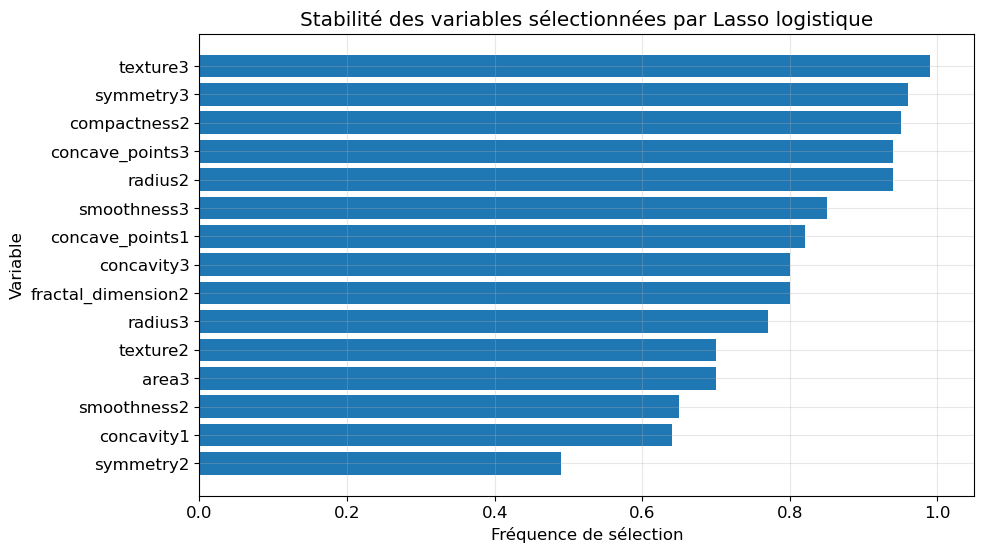

In [25]:
# Affichage des variables les plus stables
top_k = 15
top_variables = stability_df.head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(
    top_variables['Variable'][::-1],
    top_variables['Frequence_selection'][::-1]
)

plt.xlabel('Fréquence de sélection')
plt.ylabel('Variable')
plt.title('Stabilité des variables sélectionnées par Lasso logistique')
plt.xlim(0, 1.05)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [26]:
# Variables très stables
stable_vars = stability_df[stability_df['Frequence_selection'] >= 0.8]

# Variables moyennement stables
medium_vars = stability_df[
    (stability_df['Frequence_selection'] >= 0.5) &
    (stability_df['Frequence_selection'] < 0.8)
]

# Variables instables
unstable_vars = stability_df[stability_df['Frequence_selection'] < 0.5]

print("Variables très stables :")
print(stable_vars[['Variable', 'Frequence_selection']])

print("\nVariables moyennement stables :")
print(medium_vars[['Variable', 'Frequence_selection']])

print("\nNombre de variables rarement sélectionnées :", len(unstable_vars))

Variables très stables :
              Variable  Frequence_selection
21            texture3                 0.99
28           symmetry3                 0.96
15        compactness2                 0.95
27     concave_points3                 0.94
10             radius2                 0.94
24         smoothness3                 0.85
7      concave_points1                 0.82
26          concavity3                 0.80
19  fractal_dimension2                 0.80

Variables moyennement stables :
       Variable  Frequence_selection
20      radius3                 0.77
11     texture2                 0.70
23        area3                 0.70
14  smoothness2                 0.65
6    concavity1                 0.64

Nombre de variables rarement sélectionnées : 16


On observe que certaines variables sont sélectionnées dans une grande majorité des échantillons bootstrap. Ces variables peuvent être considérées comme les plus robustes du point de vue du Lasso logistique. Cette analyse est importante car le Lasso ne fournit pas seulement un modèle prédictif : il est aussi utilisé comme méthode de sélection de variables. Or, si la sélection change fortement lorsque les données changent légèrement, il faut être prudent dans l'interprétation médicale des coefficients. Les variables avec une fréquence de sélection élevée sont donc plus fiables pour l'interprétation. Au contraire, les variables sélectionnées rarement ne doivent pas être considérées comme des facteurs déterminants.

## Bonus 3 : Comparaison entre Lasso, Ridge et Elastic Net

On compare maintenant trois méthodes de régularisation pour la régression logistique :

- **Ridge** : pénalisation L2. Elle réduit les coefficients, mais ne les met presque jamais exactement à zéro.
- **Lasso** : pénalisation L1. Elle peut annuler certains coefficients, donc elle réalise une sélection de variables.
- **Elastic Net** : combinaison des pénalisations L1 et L2. Elle peut sélectionner des variables comme le Lasso, tout en étant plus stable lorsque plusieurs variables sont corrélées.

L'objectif est de comparer leur performance prédictive et le nombre de variables sélectionnées.

In [27]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.25,
    random_state=SEED,
    stratify=y_encoded
)

models = {
    "Ridge (L2)": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        l1_ratios=(0,),
        solver="liblinear",
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    ),

    "Lasso (L1)": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        l1_ratios=(1,),
        solver="liblinear",
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    ),

    "Elastic Net": LogisticRegressionCV(
        Cs=Cs,
        cv=5,
        solver="saga",
        l1_ratios=[0.2, 0.5, 0.8],
        max_iter=10000,
        random_state=SEED,
        use_legacy_attributes=True
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    coef = model.coef_[0]
    n_selected = np.sum(np.abs(coef) > 1e-6)

    results.append({
        "Méthode": name,
        "Accuracy": acc,
        "AUC": auc,
        "Nombre de variables sélectionnées": n_selected,
        "C optimal": model.C_[0]
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Méthode,Accuracy,AUC,Nombre de variables sélectionnées,C optimal
0,Ridge (L2),0.965035,0.997065,30,0.680272
1,Lasso (L1),0.965035,0.996855,13,1.204819
2,Elastic Net,0.965035,0.997275,28,0.724638


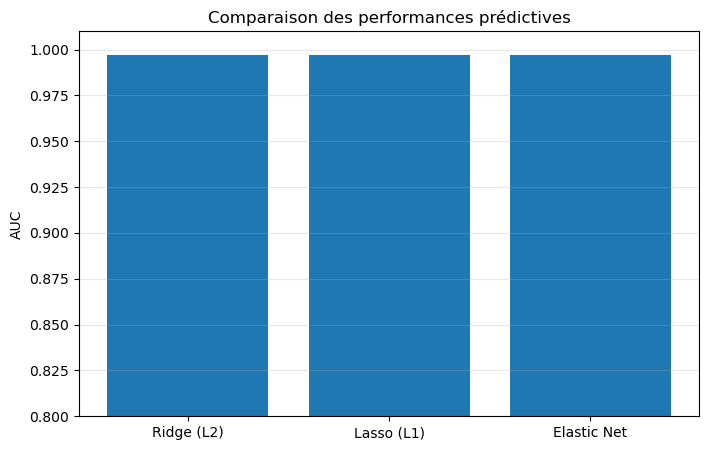

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Méthode"],
    comparison_df["AUC"]
)

plt.ylabel("AUC")
plt.title("Comparaison des performances prédictives")
plt.ylim(0.8, 1.01)
plt.grid(axis="y", alpha=0.3)
plt.show()

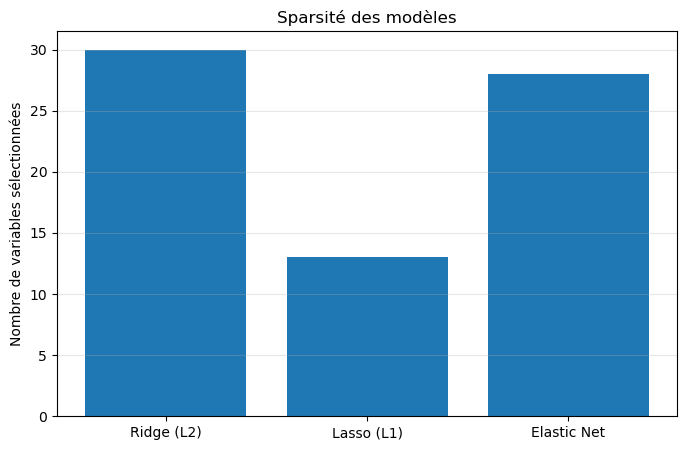

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Méthode"],
    comparison_df["Nombre de variables sélectionnées"]
)

plt.ylabel("Nombre de variables sélectionnées")
plt.title("Sparsité des modèles")
plt.grid(axis="y", alpha=0.3)
plt.show()

Les trois méthodes donnent généralement de bonnes performances prédictives sur le jeu de données du cancer du sein. Cependant, elles ne se comportent pas de la même manière du point de vue de l'interprétation.

La méthode Ridge garde toutes les variables dans le modèle, car la pénalisation L2 réduit les coefficients sans les annuler exactement. Elle est donc utile pour améliorer la stabilité du modèle, mais elle ne permet pas vraiment de sélectionner directement les variables les plus importantes.

Le Lasso, au contraire, produit un modèle plus parcimonieux. Plusieurs coefficients deviennent exactement nuls, ce qui facilite l'interprétation. Cette propriété est intéressante dans un contexte médical, car elle permet d'identifier un nombre réduit de variables potentiellement importantes.

Elastic Net représente un compromis entre Ridge et Lasso. Il conserve une partie de la capacité de sélection du Lasso, mais il est souvent plus stable lorsque certaines variables explicatives sont fortement corrélées. Cette situation est fréquente dans les données médicales, où plusieurs mesures peuvent décrire des propriétés similaires de la tumeur.

Ainsi, le choix de la méthode ne dépend pas seulement de la performance prédictive. Il dépend aussi de l'objectif de l'analyse : prédiction pure, interprétation, ou compromis entre stabilité et sélection de variables.

## Bonus 4 : Extension haute dimensionnelle

Le jeu de données **SCAN-B / GSE96058** (Brueffer et al., 2018) contient des profils d'expression RNA-seq de **3 273 tumeurs mammaires humaines**, chacune décrite par des dizaines de milliers de gènes. Contrairement à *Breast Cancer Wisconsin* ($n=569$, $p=30$), on se place ici dans un régime **haute dimension** ($p \gg n$) où le LASSO est particulièrement adapté : la pénalisation $L_1$ force la sélection automatique des gènes les plus pertinents. On cherche à prédire le **statut ER** (*Estrogen Receptor*), biomarqueur clinique binaire essentiel au choix thérapeutique.

In [9]:
DATA_DIR = Path("data_gse96058")
DATA_DIR.mkdir(exist_ok=True)

print("Téléchargement des métadonnées GSE96058...")
gse = GEOparse.get_GEO(
    geo="GSE96058",
    destdir=str(DATA_DIR),
    silent=True
)

print(f"Chargé : {len(gse.gsms)} échantillons")

expr_filename = "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
expr_path = DATA_DIR / expr_filename

expr_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96058/suppl/"
    "GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"
)

if not expr_path.exists():
    print("Fichier d'expression non trouvé localement.")
    print("Téléchargement du fichier RNA-seq depuis GEO...")
    print("Attention : le fichier fait environ 564 MB.")

    urllib.request.urlretrieve(expr_url, expr_path)

    print("Téléchargement terminé.")
else:
    print("Fichier d'expression déjà présent localement.")

print("Chemin du fichier :", expr_path)


Téléchargement des métadonnées GSE96058...
Chargé : 3409 échantillons
Fichier d'expression déjà présent localement.
Chemin du fichier : data_gse96058/GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz


In [10]:
def normalize_key(key):
    return (
        key.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


# Construction d'un tableau de métadonnées à partir des objets GSM
records = []

for gsm_id, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [gsm_id])[0]

    row = {
        "gsm_id": gsm_id,
        "sample_id": str(title)
    }

    characteristics = gsm.metadata.get("characteristics_ch1", [])

    if isinstance(characteristics, str):
        characteristics = [characteristics]

    for item in characteristics:
        item = str(item)

        if ":" in item:
            key, value = item.split(":", 1)
            row[normalize_key(key)] = value.strip()

    records.append(row)

meta_df = pd.DataFrame(records)

if "er_status" not in meta_df.columns:
    raise ValueError("La variable 'er_status' n'a pas été trouvée dans les métadonnées GEO.")

meta_df["er_status"] = pd.to_numeric(meta_df["er_status"], errors="coerce")

# On évite d'utiliser les réplicats techniques pour limiter le risque de fuite train/test
meta_df["is_replicate"] = meta_df["sample_id"].str.contains("repl", case=False, na=False)

print("Aperçu des métadonnées :")
display(meta_df[["gsm_id", "sample_id", "er_status", "is_replicate"]].head())


# Chargement de la matrice d'expression
# Lignes : gènes ; colonnes : échantillons
print("Chargement de la matrice d'expression...")
expr_df = pd.read_csv(expr_path, index_col=0)

expr_df.index = expr_df.index.astype(str)
expr_df.columns = expr_df.columns.astype(str)

print("Dimensions initiales de expr_df :", expr_df.shape)


# Alignement entre les colonnes d'expression et les métadonnées
meta_by_sample = meta_df.set_index("sample_id")
meta_by_gsm = meta_df.set_index("gsm_id")

common_sample_ids = [c for c in expr_df.columns if c in meta_by_sample.index]
common_gsm_ids = [c for c in expr_df.columns if c in meta_by_gsm.index]

if len(common_sample_ids) >= len(common_gsm_ids):
    common_cols = common_sample_ids
    meta_aligned = meta_by_sample.loc[common_cols].copy()
else:
    common_cols = common_gsm_ids
    meta_aligned = meta_by_gsm.loc[common_cols].copy()

print("Nombre d'échantillons alignés :", len(common_cols))

# On garde seulement les échantillons avec statut ER connu et sans réplicats techniques
valid_mask = (
    meta_aligned["er_status"].isin([0, 1])
    & (~meta_aligned["is_replicate"])
)

valid_cols = meta_aligned.index[valid_mask].tolist()

expr_df = expr_df.loc[:, valid_cols].copy()
expr_df = expr_df.astype(np.float32)

y_er = meta_aligned.loc[valid_cols, "er_status"].astype(int).to_numpy()

print("Dimensions après filtrage :", expr_df.shape)
print("Distribution de la cible ER :")
print(pd.Series(y_er).value_counts().rename(index={0: "ER-", 1: "ER+"}))

Aperçu des métadonnées :


,gsm_id,sample_id,er_status,is_replicate
0,GSM2528079,F1,NaN,False
1,GSM2528080,F2,1.0,False
2,GSM2528081,F3,1.0,False
3,GSM2528082,F4,1.0,False
4,GSM2528083,F5,1.0,False


Chargement de la matrice d'expression...
Dimensions initiales de expr_df : (30865, 3409)
Nombre d'échantillons alignés : 3409
Dimensions après filtrage : (30865, 3073)
Distribution de la cible ER :
ER+    2832
ER-     241
Name: count, dtype: int64


In [11]:
# Suppression des gènes à variance nulle
gene_vars = expr_df.var(axis=1)
expr_df = expr_df[gene_vars > 0]

X_geo = expr_df.T.values.astype(np.float32)
gene_names = np.array(expr_df.index)

# Suppression des NaN éventuels
mask_valid = ~np.isnan(X_geo).any(axis=1)
X_geo = X_geo[mask_valid]
y_er = y_er[mask_valid]

# Split train/test AVANT le scaling pour éviter la fuite de données
X_geo_train_raw, X_geo_test_raw, y_geo_train, y_geo_test = train_test_split(
    X_geo,
    y_er,
    test_size=0.20,
    random_state=SEED,
    stratify=y_er
)

# Standardisation, uniquement avec les données train
scaler_geo = StandardScaler()
X_geo_train = scaler_geo.fit_transform(X_geo_train_raw).astype(np.float32)
X_geo_test = scaler_geo.transform(X_geo_test_raw).astype(np.float32)

print(f"Train : {X_geo_train.shape[0]}  |  Test : {X_geo_test.shape[0]}  |  Gènes : {X_geo_train.shape[1]}")


Train : 2458  |  Test : 615  |  Gènes : 28562


In [12]:
Cs_geo = np.logspace(-3, 0, 6)

print("Entraînement du LASSO logistique haute dimension...")

clf_geo = LogisticRegressionCV(
    Cs=Cs_geo,
    cv=3,
    l1_ratios=(1,),
    solver="saga",
    max_iter=3000,
    tol=1e-3,
    scoring="roc_auc",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    use_legacy_attributes=True
)

clf_geo.fit(X_geo_train, y_geo_train)

print("Entraînement terminé.")

Entraînement du LASSO logistique haute dimension...
Entraînement terminé.


In [13]:
best_C_geo = float(np.atleast_1d(clf_geo.C_)[0])
best_lambda_geo = 1 / best_C_geo

coef_geo = np.atleast_2d(clf_geo.coef_)[0]

threshold_geo = 1e-4
active_mask_geo = np.abs(coef_geo) > threshold_geo

n_active_geo = np.sum(active_mask_geo)

print(f"C optimal : {best_C_geo:.4f}")
print(f"Lambda optimal : {best_lambda_geo:.4f}")
print(f"Gènes sélectionnés par LASSO : {n_active_geo} / {len(gene_names)}")
print()

y_pred_geo = clf_geo.predict(X_geo_test)
y_proba_geo = clf_geo.predict_proba(X_geo_test)[:, 1]

acc_geo = accuracy_score(y_geo_test, y_pred_geo)
auc_geo = roc_auc_score(y_geo_test, y_proba_geo)
cm_geo = confusion_matrix(y_geo_test, y_pred_geo)

print(f"Accuracy test : {acc_geo:.4f}")
print(f"AUC test : {auc_geo:.4f}")
print("Matrice de confusion :")
print(cm_geo)


C optimal : 0.0631
Lambda optimal : 15.8489
Gènes sélectionnés par LASSO : 1546 / 28562

Accuracy test : 0.9512
AUC test : 0.9525
Matrice de confusion :
[[ 44   4]
 [ 26 541]]


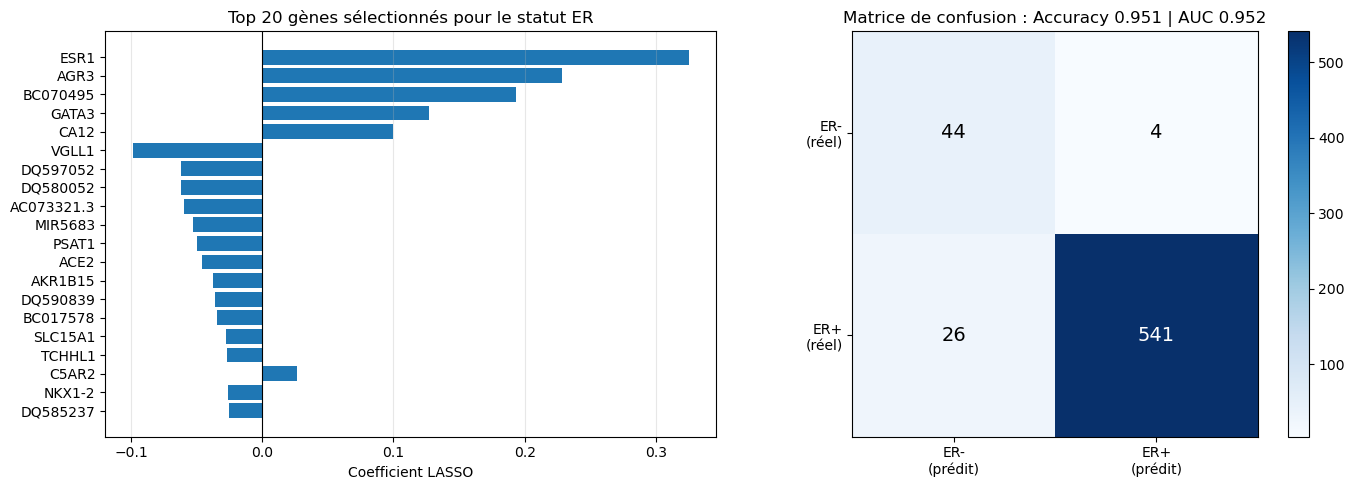

In [15]:
active_gene_names = np.array(gene_names)[active_mask_geo]
active_coefs_geo = coef_geo[active_mask_geo]

sorted_idx = np.argsort(np.abs(active_coefs_geo))[::-1]
top_k = min(20, len(sorted_idx))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    active_gene_names[sorted_idx[:top_k]][::-1],
    active_coefs_geo[sorted_idx[:top_k]][::-1]
)

axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Coefficient LASSO")
axes[0].set_title(f"Top {top_k} gènes sélectionnés pour le statut ER")
axes[0].grid(axis="x", alpha=0.3)

im = axes[1].imshow(cm_geo, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["ER-\n(prédit)", "ER+\n(prédit)"])
axes[1].set_yticklabels(["ER-\n(réel)", "ER+\n(réel)"])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, str(cm_geo[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_geo[i, j] > cm_geo.max() / 2 else "black"
        )

axes[1].set_title(f"Matrice de confusion : Accuracy {acc_geo:.3f} | AUC {auc_geo:.3f}")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

### Interprétation

Les résultats montrent que le LASSO logistique reste efficace dans un cadre véritablement haute dimension : $p = 28\,562$ gènes pour $n = 2\,458$ échantillons d'entraînement, soit un rapport $p/n \approx 12$. Aucune présélection n'a été appliquée au-delà du filtrage des gènes à variance nulle, ce qui fait du LASSO le seul mécanisme de réduction de dimension.

Le modèle obtient une accuracy de $0.951$ et une AUC de $0.953$ sur l'ensemble de test. La matrice de confusion montre que les tumeurs ER+ sont très bien identifiées (541 sur 567 correctement classées), tandis que les tumeurs ER- restent plus difficiles à détecter (44 sur 48), ce qui s'explique par leur faible représentation dans les données (241 ER- contre 2832 ER+). L'utilisation de `class_weight="balanced"` est essentielle pour ne pas ignorer cette minorité.

Le LASSO sélectionne 1546 gènes parmi les 28562 disponibles ($\lambda^* \approx 15.85$), soit environ 5\% du total. Cela illustre bien l'intérêt de la pénalisation $L_1$ en haute dimension : elle construit un modèle prédictif tout en annulant la grande majorité des coefficients. L'interprétation biologique des gènes retenus doit cependant rester prudente : la corrélation entre gènes et le déséquilibre des classes peuvent influencer la sélection finale.
